In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# For regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from mpl_toolkits.mplot3d import axes3d

from sklearn.preprocessing import scale
import sklearn.linear_model as skl_lm
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [34]:
dataset= pd.read_csv('D:/Github_project/Student_Performance.csv')

In [36]:
dataset

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [38]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [40]:
dataset['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

In [42]:
dataset['Extracurricular_Activities']=dataset['Extracurricular Activities'].map({'Yes':1,'No':0})

In [44]:
dataset.drop('Extracurricular Activities', axis=1, inplace=True)

In [72]:
dataset['Performance_Index']=dataset['Performance Index']
dataset.drop('Performance Index', axis=1, inplace=True)

<Axes: xlabel='Hours Studied', ylabel='Performance_Index'>

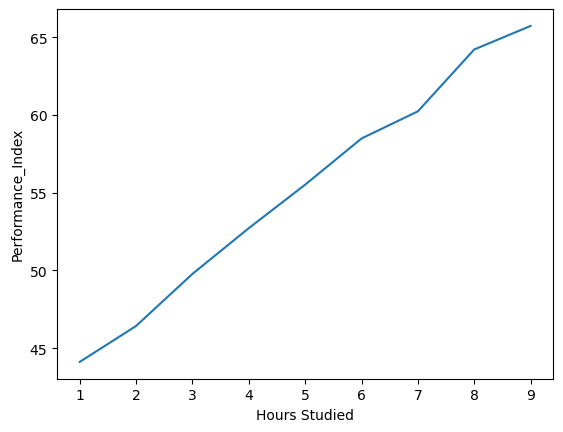

In [76]:
Study_Hours= dataset.groupby('Hours Studied')['Performance_Index'].mean().reset_index()
sns.lineplot(data=Study_Hours, x='Hours Studied', y='Performance_Index')

<Axes: xlabel='Hours Studied', ylabel='Performance_Index'>

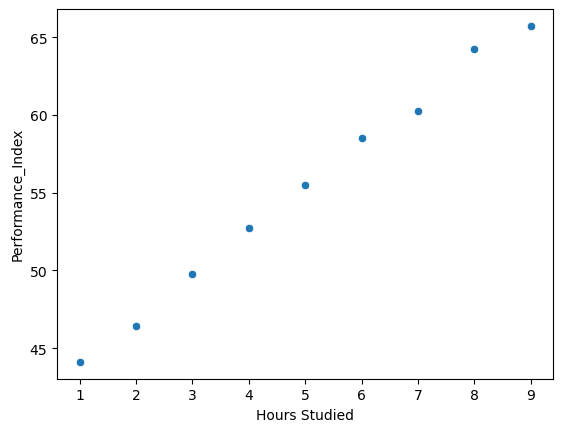

In [78]:
sns.scatterplot(data=Study_Hours, x='Hours Studied', y='Performance_Index')

<Axes: xlabel='Extracurricular_Activities', ylabel='Performance_Index'>

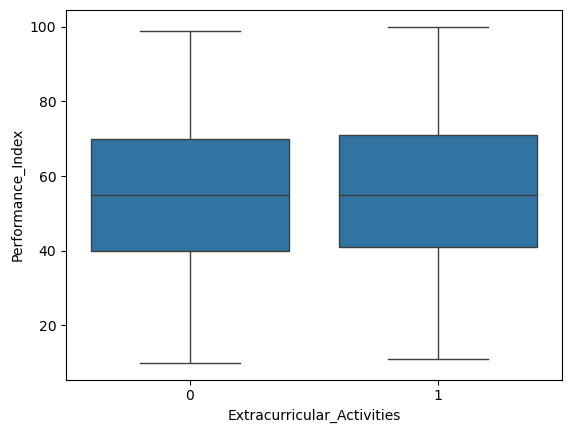

In [80]:
sns.boxplot(data=dataset, x='Extracurricular_Activities', y='Performance_Index')

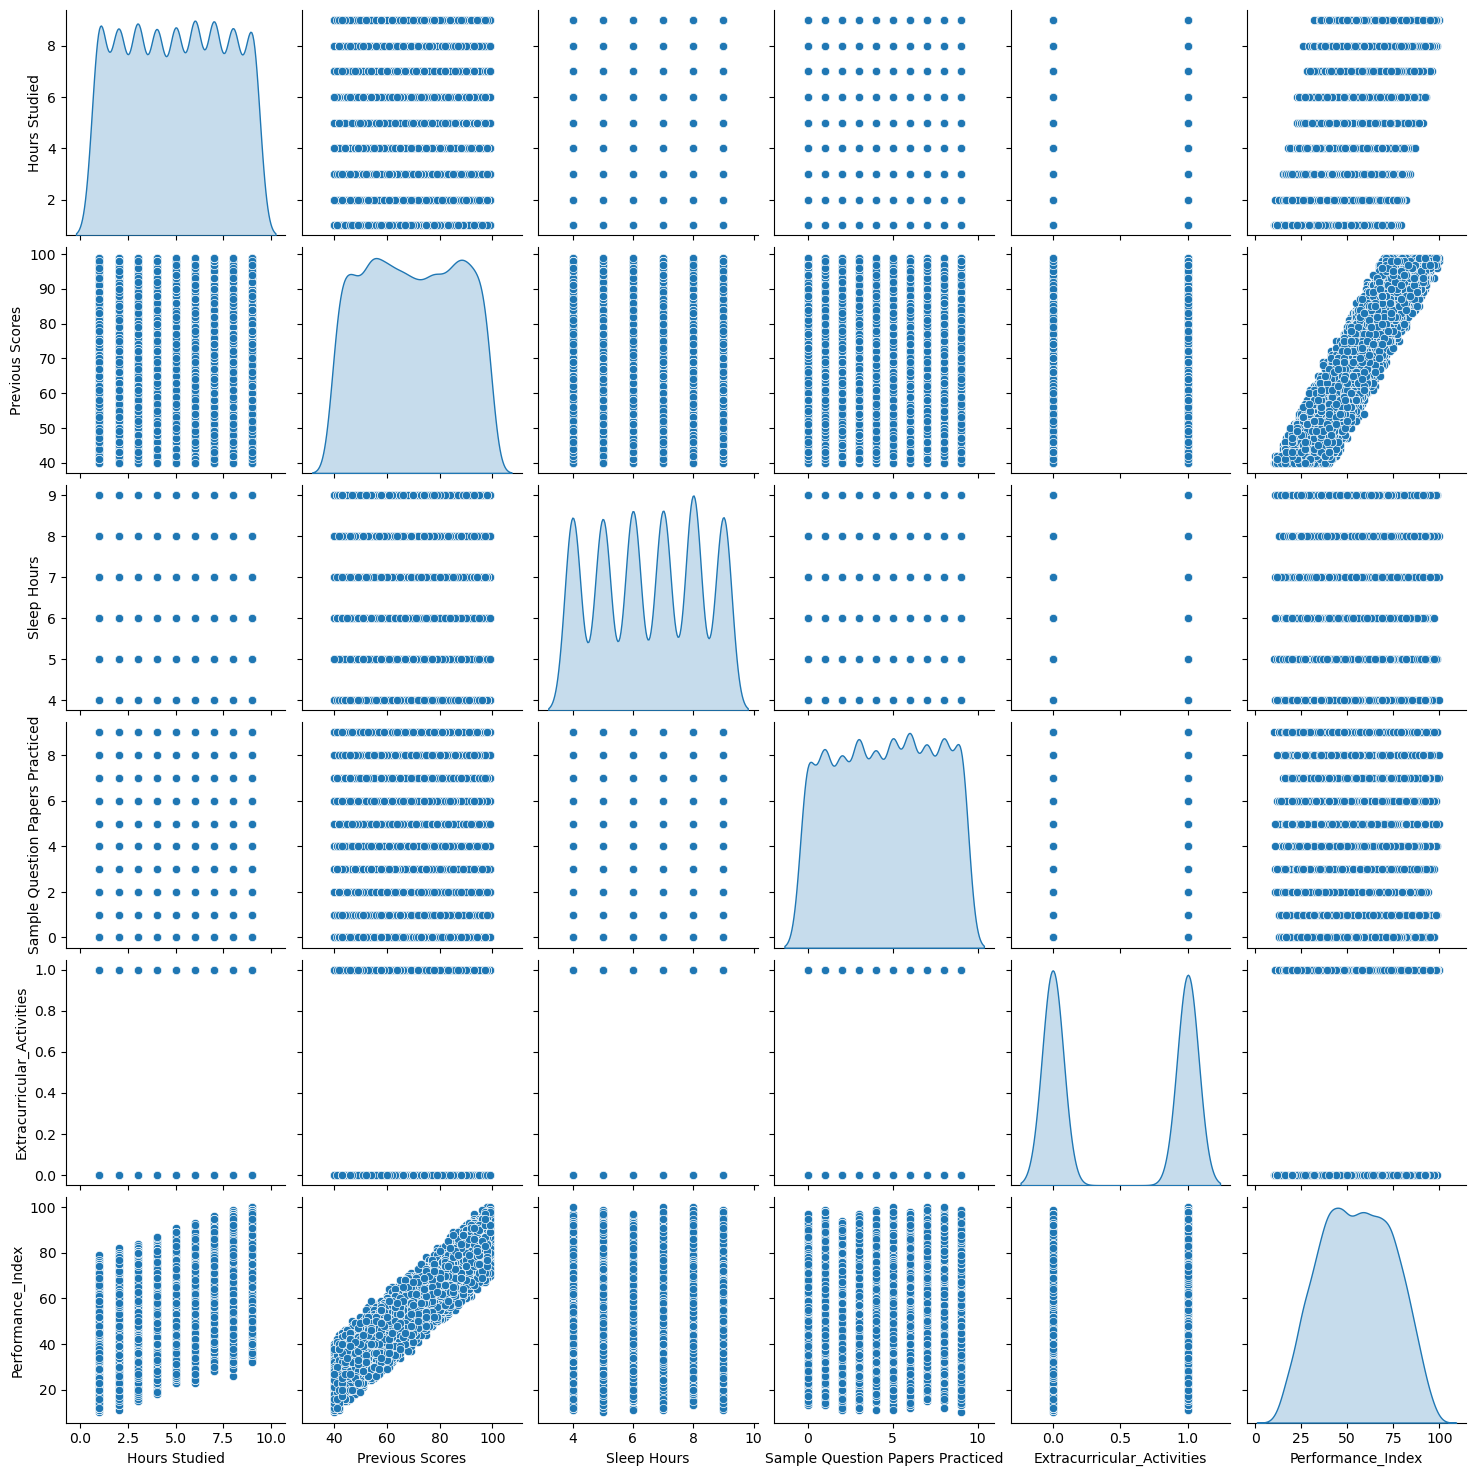

In [82]:
sns.pairplot(dataset, diag_kind='kde')

In [84]:
corr= dataset.corr()

In [86]:
corr

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular_Activities,Performance_Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.003873,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.008369,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,-0.023284,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.013103,0.043268
Extracurricular_Activities,0.003873,0.008369,-0.023284,0.013103,1.000000,0.024525
Performance_Index,0.373730,0.915189,0.048106,0.043268,0.024525,1.000000


<Axes: >

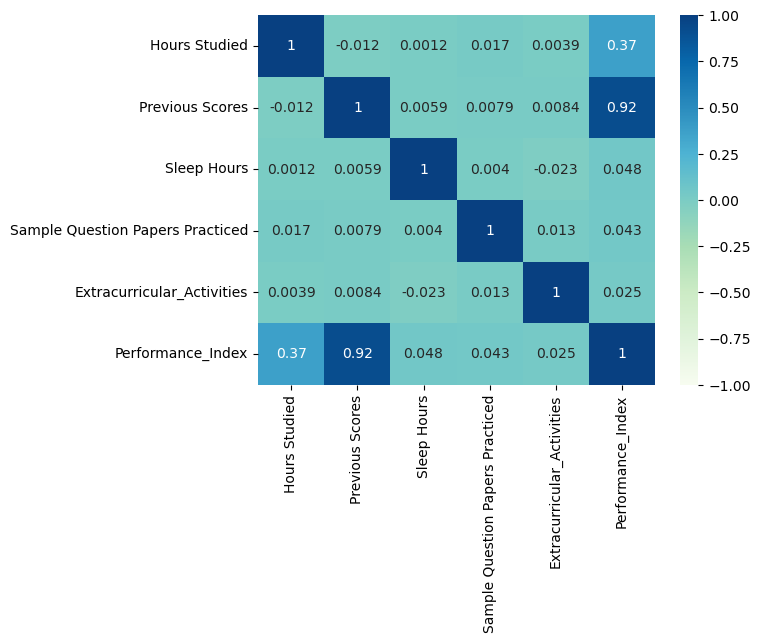

In [88]:
corr = dataset.corr()
sns.heatmap(corr, vmax=1, vmin=-1, annot=True, cmap='GnBu')

Reffering to correlation- we can say that Hour Studied has weak linear relation with Performance Index and Previous Scores have a strong linear relation with Performance Index. 
Rest feature/ parameter shows very weak relation

In [107]:
est = smf.ols('Performance_Index ~ Q("Hours Studied")', data=dataset).fit()
est.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,41.3792,0.387,106.890,0.000,40.620,42.138
"Q(""Hours Studied"")",2.7731,0.069,40.289,0.000,2.638,2.908


In [109]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Performance_Index   R-squared:                       0.140
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     1623.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:13:32   Log-Likelihood:                -42992.
No. Observations:               10000   AIC:                         8.599e+04
Df Residuals:                    9998   BIC:                         8.600e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             41.3792      0.387    106.890      0.000      40.620      42.138
Q("Hours Studied")     2.7731      0.069     40.289      0.000       2.638       2.908
==============================================================================
Omnibus:                     6751.810   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              570.766
Skew:                           0.002   Prob(JB):                    1.15e-124
Kurtosis:                       1.830   Cond. No.                         12.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [111]:
est = smf.ols(
    'Performance_Index ~ Q("Hours Studied") + Q("Previous Scores")',
    data=dataset
).fit()

print(est.summary().tables[1])

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -29.8168      0.105   -285.248      0.000     -30.022     -29.612
Q("Hours Studied")       2.8576      0.009    323.947      0.000       2.840       2.875
Q("Previous Scores")     1.0191      0.001    773.815      0.000       1.017       1.022


In [113]:
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      Performance_Index   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 3.488e+05
Date:                Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:15:07   Log-Likelihood:                -22446.
No. Observations:               10000   AIC:                         4.490e+04
Df Residuals:                    9997   BIC:                         4.492e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              -29.8168      0.105   -285.248      0.000     -30.022     -29.612
Q("Hours Studied")       2.8576      0.009    323.947      0.000       2.840       2.875
Q("Previous Scores")     1.0191      0.001    773.815      0.000       1.017       1.022
==============================================================================
Omnibus:                        2.786   Durbin-Watson:                   1.992
Prob(Omnibus):                  0.248   Jarque-Bera (JB):                2.844
Skew:                           0.016   Prob(JB):                        0.241
Kurtosis:                       3.077   Cond. No.                         329.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [115]:
x= dataset.drop(['Performance_Index','Sleep Hours','Sample Question Papers Practiced','Extracurricular_Activities'], axis=1)

In [117]:
y=dataset['Performance_Index']

In [119]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(x, y, test_size=0.3, random_state = 1)

In [121]:
X_train1

,Hours Studied,Previous Scores
2228,4,85
5910,2,77
1950,3,45
2119,6,94
5947,5,92
...,...,...
2895,5,68
7813,3,45
905,8,93
5192,3,98


In [125]:
X_test1

,Hours Studied,Previous Scores
9953,6,73
3850,1,89
4962,3,97
3886,8,70
5437,7,94
...,...,...
5273,2,70
8014,6,42
8984,6,98
6498,1,88


In [127]:
y_train1

2228    66.0
5910    52.0
1950    30.0
2119    83.0
5947    78.0
        ... 
2895    53.0
7813    26.0
905     85.0
5192    76.0
235     38.0
Name: Performance_Index, Length: 7000, dtype: float64

In [129]:
y_test1

9953    58.0
3850    64.0
4962    75.0
3886    59.0
5437    86.0
        ... 
5273    51.0
8014    32.0
8984    87.0
6498    68.0
6327    47.0
Name: Performance_Index, Length: 3000, dtype: float64

In [131]:
print(X_train1.shape)
print(X_test1.shape)
print(y_train1.shape)
print(y_test1.shape)

(7000, 2)
(3000, 2)
(7000,)
(3000,)


In [133]:
reg_model= LinearRegression()
reg_model.fit(X_train1,y_train1)

LinearRegression()

In [135]:
reg_model.coef_

array([2.85820395, 1.01856542])

In [184]:
print(reg_model.coef_[0])
print(reg_model.coef_[1])

2.8582039451373653
1.0185654184035642


In [137]:
print("Intercept: ", reg_model.intercept_)

Intercept:  -29.76137450569371


In [139]:
reg_model.score(X_train1, y_train1)

0.9861626048254155

In [141]:
y_predict = reg_model.predict(X_test1)
y_predict

array([61.74312471, 63.74915168, 77.61408291, ..., 87.20726017,
       62.73058626, 45.41497415])

In [149]:
print(y_predict.shape)

(3000,)


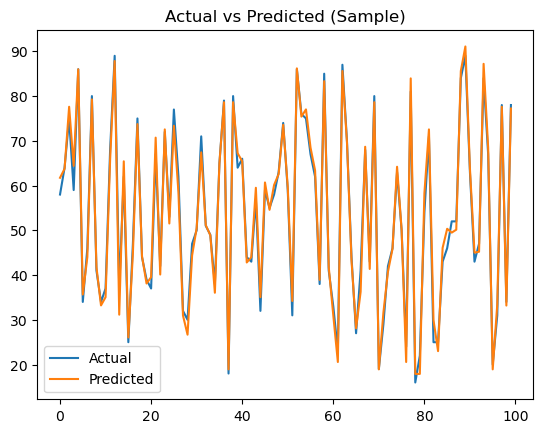

In [157]:
plt.plot(y_test1.values[:100], label="Actual")
plt.plot(y_predict[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (Sample)")
plt.show()

Text(0.5, 0, 'Performance Index')

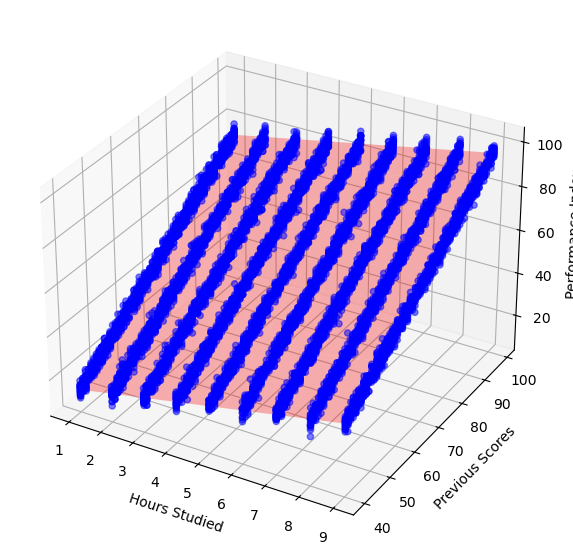

In [186]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot (actual data)
ax.scatter(
    dataset['Hours Studied'],
    dataset['Previous Scores'],
    dataset['Performance_Index'],
    color='blue',
    alpha=0.5
)

# Create grid for plane
x = np.linspace(dataset['Hours Studied'].min(), dataset['Hours Studied'].max(), 10)
y = np.linspace(dataset['Previous Scores'].min(), dataset['Previous Scores'].max(), 10)
x, y = np.meshgrid(x, y)

# Predict using your model
z = reg_model.intercept_ + reg_model.coef_[0]*x + reg_model.coef_[1]*y

# Plot regression plane
ax.plot_surface(x, y, z, color='red', alpha=0.3)

ax.set_xlabel("Hours Studied")
ax.set_ylabel("Previous Scores")
ax.set_zlabel("Performance Index")

# Blue points represents the actual dataset, Performance is almost linear combination of Hours Studied and Previous Scores
# Red plane fits closely to the blue points

In [167]:
test_input =[[9,99]]
print(f'Predicted Performance for 9 hr study and 99 as previous score: {reg_model.predict(test_input)}')

Predicted Performance for 9 hr study and 99 as previous score: [96.80043742]


C:\Users\Home\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [169]:
test_input_2 =[[4,99]]
print(f'Predicted Performance for 4 hr study and 99 as previous score: {reg_model.predict(test_input_2)}')

Predicted Performance for 4 hr study and 99 as previous score: [82.5094177]


C:\Users\Home\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
